## 🗂️ Locations

**Reference:** [Location repositories](../reference/input_formats.md#location-repositories) **Advanced API:** [🗂️ Locations](lo12_locations.ipynb)

This notebook demonstrates how _OptiWindNet_ can load all `.osm.pbf` and `.yaml` files from a directory into a _namedtuple_ of NetworkX graphs, which can be used to initialize a [WindFarmNetwork()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) instance. See [Location repositories](../reference/input_formats.md#location-repositories) for what a repository is and what the bundled one contains.

### Import required modules

Import [load_repository()](../autoapi/optiwindnet/importer/index.rst#optiwindnet.importer.load_repository) and [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork).

In [ ]:
import pprint

from tabulate import tabulate

In [2]:
from optiwindnet.api import WindFarmNetwork, load_repository

In [3]:
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

### Load a repository

[load_repository()](../autoapi/optiwindnet/importer/index.rst#optiwindnet.importer.load_repository) (without arguments) reads the `.osm.pbf` and `.yaml` locations distributed with _OptiWindNet_. The function returns a _namedtuple_ of NetworkX graphs containing location data.

> Note: `load_repository('path/to/custom/repo')` instead loads all `.osm.pbf` and `.yaml` files from the custom repository in that directory.

In [4]:
locations = load_repository()

In [5]:
pprint.pp(sorted(locations._fields), compact=True)
print(f'Location count: {len(locations)}')

['albatros', 'amalia', 'amrumbank', 'anglia', 'anglia3', 'anholt', 'arkona',
 'baltic2', 'bard', 'beatrice', 'belwind', 'binhainorthH2', 'bodhi', 'borkum',
 'borkum2', 'borkum3', 'borssele', 'brieuc', 'bucht', 'butendiek',
 'cazzaro_2022', 'cazzaro_2022G140', 'cazzaro_2022G210', 'changhua1',
 'coastalva', 'dantysk', 'doggerA', 'doggerB', 'doggerC', 'dudgeon', 'eagle',
 'fecamp', 'gabbin', 'galloper', 'gangkou1', 'gangkou2', 'gemini1', 'gemini2',
 'glotech1', 'gode', 'gwynt', 'hedreiht', 'hohesee', 'horns', 'horns2',
 'horns3', 'hornsea', 'hornsea2', 'hornsea2w', 'humber', 'inchcape', 'jiaxing1',
 'kaskasi', 'kfA', 'kfB', 'kustnoord', 'kustzuid', 'lillgrund', 'lincs',
 'london', 'luchterduinen', 'meerwind', 'merkur', 'mermaid', 'morayeast',
 'moraywest', 'nanpeng', 'nazaire', 'neart', 'noirmoutier', 'nordsee',
 'nordseeost', 'norther', 'northwind', 'nysted', 'ormonde', 'race', 'rampion',
 'rental', 'revolution', 'riffgat', 'robin', 'rough', 'rudongH10', 'rudongH6',
 'rudongH8', 'rudongd

Each location is loaded as a NetworkX graph containing location data.

In [6]:
type(locations.seagreen)

networkx.classes.graph.Graph

### Use loaded locations

Initialize an instance of [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) with one of the locations (e.g. seagreen).

In [7]:
wfn = WindFarmNetwork(L=locations.seagreen, cables=[(2, 1500.0), (5, 1800.0)])

#### Plot location

> **Note:** [wfn.plot_location()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot_location) plots the location explicitly. See [📊 Plotting](hi14_plotting.ipynb) for the available plotting methods.

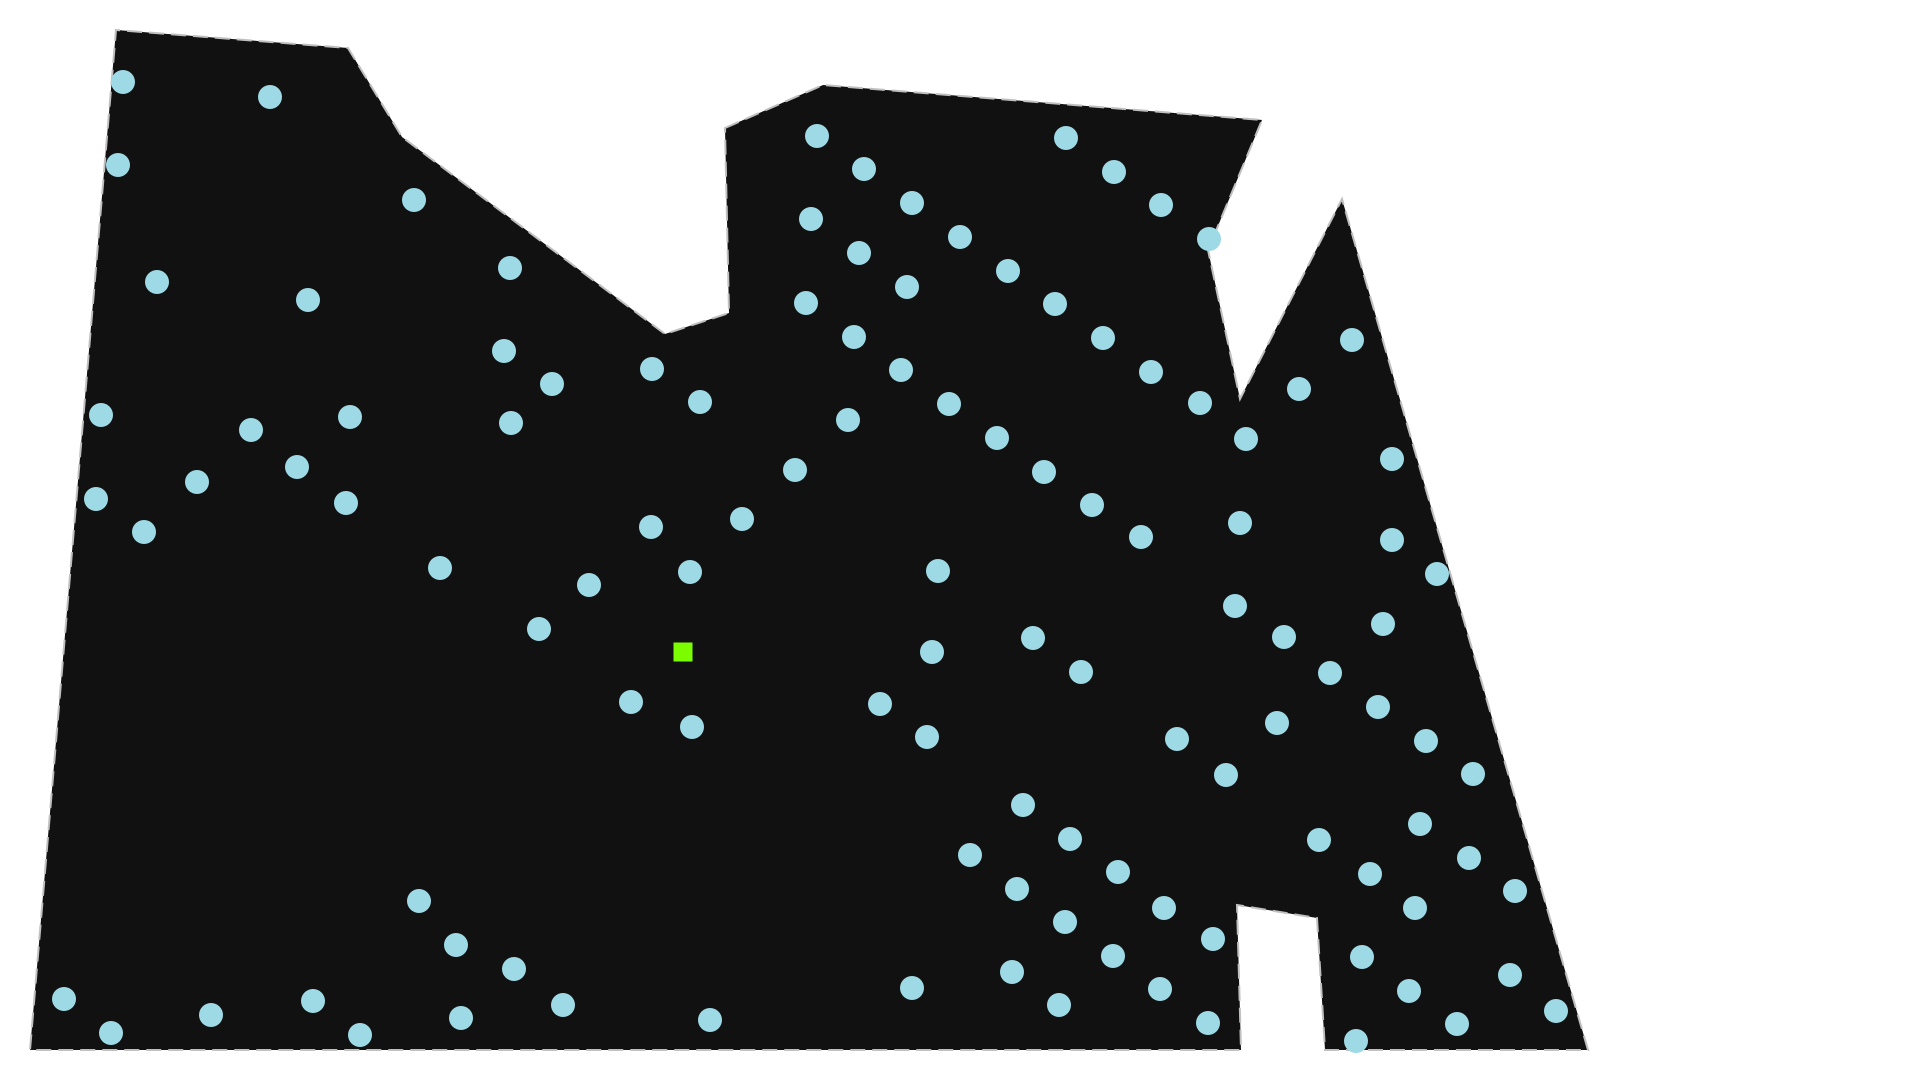

In [8]:
wfn

### List the locations in OptiWindNet's repository

List, for all available locations:

- `name`: long form location name
- `handle`: short identifier
- `R`: number of Roots (Substations)
- `T`: number of Terminals (Turbines)

In [ ]:
rows = [
    (L.graph['name'], L.graph['handle'], L.graph['R'], L.graph['T'])
    for L in sorted(locations, key=lambda loc: loc.graph['name'])
]
tabulate(rows, headers=('name', 'handle', 'R', 'T'), tablefmt='html')

Any of the locations in this list can be directly passed to [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) instance as `L` graph, e.g.:

```python
 wfn = WindFarmNetwork(L=locations.seagreen, cables=7)
```